In [ ]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Preprocesado y modelado
# ==============================================================================
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import multiprocessing
from sklearn.metrics import mean_squared_error
from google.colab import files


# Configuración warnings
# ==============================================================================
import warnings

print(f"Versión de scikit-learn: {sklearn.__version__}")

Versión de scikit-learn: 1.6.1


In [ ]:
#Lectura de datos
# ==============================================================================

import os
if not os.path.exists('/content/drive/MyDrive'):
  from google.colab import drive
  drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Laboratorio de Ciencia de Datos/Bases de Datos/Grupo 1 - Aprobación de Créditos.csv')

Mounted at /content/drive


#Exploracion Inicial de los datos:



In [ ]:
print("Primeras filas del dataset:")
display(df.head(10))

print("\nResumen del DataFrame:")
df.info()

print("\nEstadísticas descriptivas:") # Estadísticas generales (sólo para columnas numéricas)
display(df.describe())

print("\nDistribución de la variable objetivo (Loan_Status):") # Ver las clases de la variable objetivo
print(df['Loan_Status'].value_counts(normalize=True))

Primeras filas del dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N



Resumen del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Estadísticas descriptivas:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



Distribución de la variable objetivo (Loan_Status):
Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64


##Limpieza de Datos

Hay datos de tipo categórico pero como Object y muchos datos nulos.

In [ ]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


Vamos a convertir las variables Object a categóricas excepto Loan_ID.

In [ ]:
df = df.drop('Loan_ID', axis=1) #Elimino Loan_ID porque es un identificador, no un predictor
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.Categorical(df[col])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             601 non-null    category
 1   Married            611 non-null    category
 2   Dependents         599 non-null    category
 3   Education          614 non-null    category
 4   Self_Employed      582 non-null    category
 5   ApplicantIncome    614 non-null    int64   
 6   CoapplicantIncome  614 non-null    float64 
 7   LoanAmount         592 non-null    float64 
 8   Loan_Amount_Term   600 non-null    float64 
 9   Credit_History     564 non-null    float64 
 10  Property_Area      614 non-null    category
 11  Loan_Status        614 non-null    category
dtypes: category(7), float64(4), int64(1)
memory usage: 29.2 KB


#Imputacion de variables faltantes

Para las variables categóricas con valores faltantes, se utilizó la imputación por la moda. Dado que la moda representa la categoría más frecuente, lo cual es una estimación razonable. Además, esta técnica permite preservar el tamaño del conjunto de datos sin eliminar registros potencialmente importantes.

In [ ]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)


print("Valores nulos restantes:\n", df.isnull().sum())

Valores nulos restantes:
 Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


/tmp/ipython-input-6-2621063304.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


###Variable **Credit_History**

Credit_History es una variable poco clara que parece tomar solo valores 0.0 y 1.0. Vamos a hacer un histograma por la sospecha de que sea categórica.

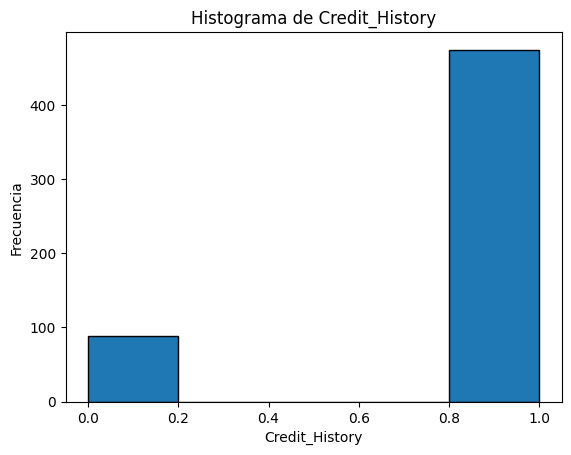

In [ ]:
plt.hist(df['Credit_History'], bins=5, edgecolor='black')
plt.xlabel('Credit_History')
plt.ylabel('Frecuencia')
plt.title('Histograma de Credit_History')

plt.show()

Efectivamente era categórica (0.0 = Mal historial crediticio y 1.0 = Buen historial crediticio).

Tiene bastantes datos faltantes que podríamos descartar, pero  la cantidad de datos es significativa (50/614 =  8.1%).

Imputar por la moda no sería razonable porque hay un gran desbalance entre las dos categorías y solo acentuaría el problema.

La estrategia más sencilla, será crear una nueva categoría con valor -1 para estos casos de forma que el modelo entienda que ese dato faltan y pueda actuar en consecuencia.

In [ ]:
df['Credit_History'] = df['Credit_History'].fillna(-1)

#Pasar a categórica

df['Credit_History'] = df['Credit_History'].astype('int')

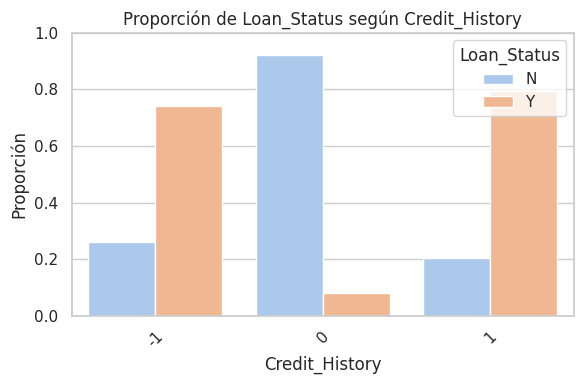

In [ ]:
# Estilo gráfico
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (6, 4)

# Variable específica
var = 'Credit_History'

# Crear tabla de proporciones
prop_df = (
    df.groupby([var, 'Loan_Status'], observed=True).size().reset_index(name='count')
)

# Calcular proporción dentro de cada categoría de la variable
total_per_category = prop_df.groupby(var)['count'].transform('sum')
prop_df['proportion'] = prop_df['count'] / total_per_category

# Graficar
plt.figure()
sns.barplot(data=prop_df, x=var, y='proportion', hue='Loan_Status')
plt.title(f'Proporción de Loan_Status según {var}')
plt.xlabel(var)
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.legend(title='Loan_Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###Variable **LoanAmount**

Visualizamos con un histograma

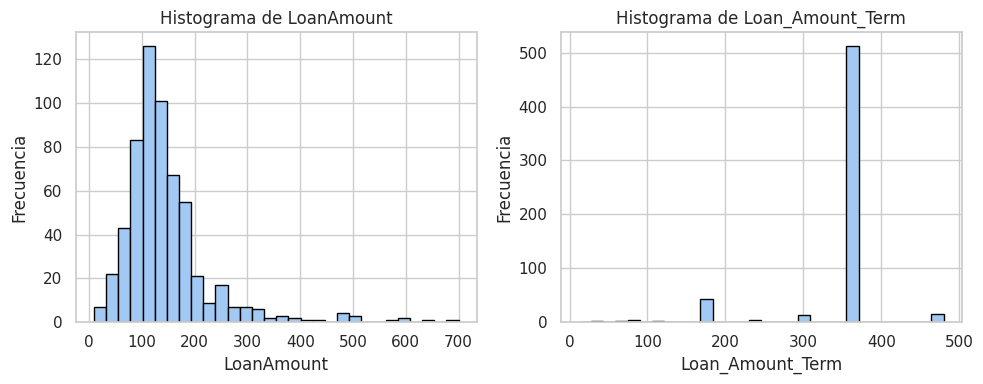

In [ ]:
columnas_a_graficar = ['LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for i, columna in enumerate(columnas_a_graficar):
    ax = axes[i]
    ax.hist(df[columna].dropna(), bins=30, edgecolor='black')

    ax.set_title(f'Histograma de {columna}')
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#Ver despues la variable Loan_Amount_Term y cambiarlo por un grafico de barras

`Loan_Amount_Term` parece ser la cantidad de cuotas del prestamo con un pico en 360 meses (10 años).

In [ ]:
categorias_loan_term = df['Loan_Amount_Term'].dropna().unique()
categorias_loan_term.sort()
print("Las categorías (valores únicos) de Loan_Amount_Term son:")
for i in categorias_loan_term:
  print(f"Cuotas de {int(i)} meses: {df[df['Loan_Amount_Term'] == i].shape[0]} datos")


Las categorías (valores únicos) de Loan_Amount_Term son:
Cuotas de 12 meses: 1 datos
Cuotas de 36 meses: 2 datos
Cuotas de 60 meses: 2 datos
Cuotas de 84 meses: 4 datos
Cuotas de 120 meses: 3 datos
Cuotas de 180 meses: 44 datos
Cuotas de 240 meses: 4 datos
Cuotas de 300 meses: 13 datos
Cuotas de 360 meses: 512 datos
Cuotas de 480 meses: 15 datos


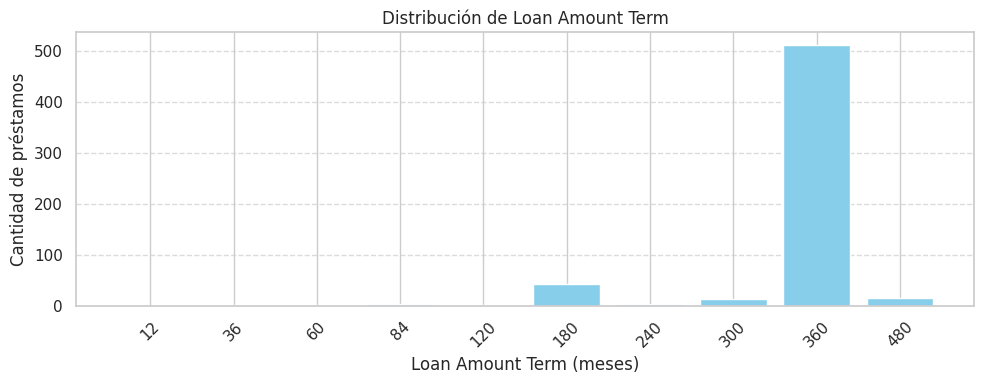

In [ ]:
# posible grafico de barras, reemplazando el histograma....

import matplotlib.pyplot as plt

# Contar la frecuencia de cada valor único en Loan_Amount_Term
loan_term_counts = df['Loan_Amount_Term'].value_counts().sort_index()

# Crear el gráfico de barras
plt.figure(figsize=(10,4))
plt.bar(loan_term_counts.index.astype(int).astype(str), loan_term_counts.values, color='skyblue')

# Personalizar el gráfico
plt.xlabel('Loan Amount Term (meses)')
plt.ylabel('Cantidad de préstamos')
plt.title('Distribución de Loan Amount Term')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


Como solo tenemos 14 datos faltantes, los imputaremos por la moda

In [ ]:
loan_amount_term_moda = df['Loan_Amount_Term'].mode()[0]
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(loan_amount_term_moda)

Seguimos con `LoadAmount`. Parece ser una distribución normal con un leve sezgo a la derecha. Vamos a verificarlo:

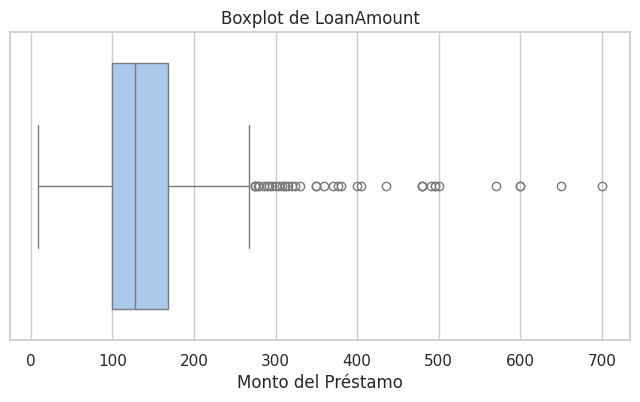

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['LoanAmount'])
plt.title('Boxplot de LoanAmount')
plt.xlabel('Monto del Préstamo')
plt.show()

In [ ]:
asimetria = df['LoanAmount'].skew()
curtosis = df['LoanAmount'].kurt() # 0 es dist. normal según documentación

print(f"Asimetría de LoanAmount: {asimetria:.2f}")
print(f"Curtosis de LoanAmount: {curtosis:.2f}")

Asimetría de LoanAmount: 2.68
Curtosis de LoanAmount: 10.40


El valor tan alto de la curtosis refleja que la distribución definitivamente no es Normal y es bastante puntiaguda y con colas alargadas, además tiene un sesgo para la derecha importante por lo que imputar por la mediana será lo correcto.


In [ ]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

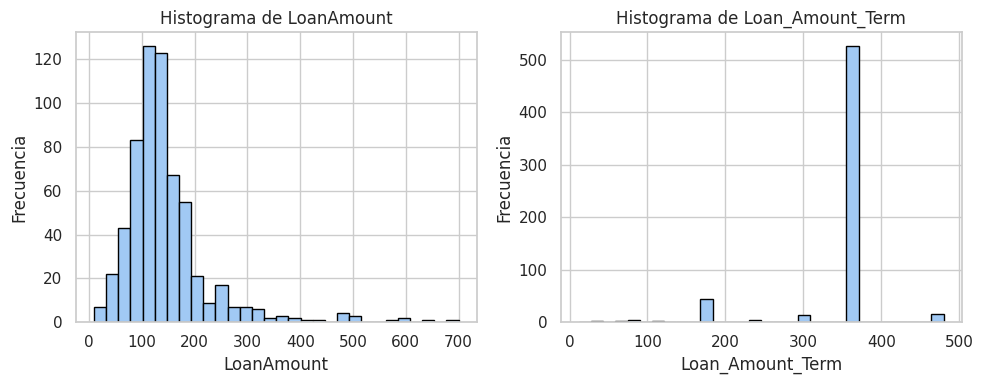

In [ ]:
columnas_a_graficar = ['LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for i, columna in enumerate(columnas_a_graficar):
    ax = axes[i]
    ax.hist(df[columna].dropna(), bins=30, edgecolor='black')

    ax.set_title(f'Histograma de {columna}')
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Variable **Self_Employed**

In [ ]:
porcentaje_de_nulos_SE = df["Self_Employed"].isnull().sum()/df.shape[0]*100
print(f"El porcentaje de nulos de Self_Employed es: {porcentaje_de_nulos_SE:.2f}%")


El porcentaje de nulos de Self_Employed es: 0.00%


No presenta tantos datos faltantes por lo que haremos un analisis para saber si descartarlos directamente o imputarlos de alguna forma.

In [ ]:
df["Self_Employed"].head()

,Self_Employed
0,No
1,No
2,Yes
3,No
4,No


Es una variable categórica con solo dos opciones: `Yes` en el caso de que sea trabajador independiente y `No` en el caso de que tenga trabajo en relación de dependencia.

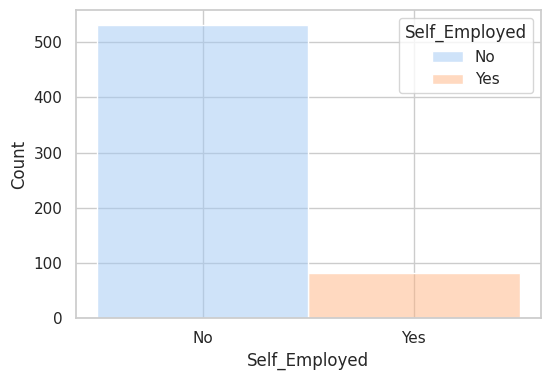

In [ ]:
hist_se = sns.histplot(data = df, x = df["Self_Employed"], hue = "Self_Employed")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             614 non-null    category
 1   Married            614 non-null    category
 2   Dependents         614 non-null    category
 3   Education          614 non-null    category
 4   Self_Employed      614 non-null    category
 5   ApplicantIncome    614 non-null    int64   
 6   CoapplicantIncome  614 non-null    float64 
 7   LoanAmount         614 non-null    float64 
 8   Loan_Amount_Term   614 non-null    float64 
 9   Credit_History     614 non-null    int64   
 10  Property_Area      614 non-null    category
 11  Loan_Status        614 non-null    category
dtypes: category(7), float64(3), int64(2)
memory usage: 29.2 KB


#Variable **Dependents**
En esta variable la categoria '3+' indica que una persona tiene 3 o mas dependientes. Para poder trabajar con esta variable de forma numérica, necesitamos convertirla a un numero entero.

Realizar esta simplificación, nos permite: Facilitar el análisis estadístico, evitar problemas con modelos y reducir la cardinalidad.

Se había planteado la posibilidad de considerar esta variable como categórica o como cuantitativa discreta pero como queríamos usar regresión logística que funciona con variables cuantitativas, decidimos pasarla a tipo `entero`.  

In [ ]:
# Convertimos '3+' en Dependents a 3
df['Dependents'] = df['Dependents'].replace('3+', 3).astype('int')

/tmp/ipython-input-22-1105381215.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Dependents'] = df['Dependents'].replace('3+', 3).astype('int')


#Codificacion de variables categoricas



#Label Enconder

Para la codificacion vamos a utilizar Label Encoder para transformar variables categoricas con pocas clases (binarias o casi binarias) a formato numerico. Esta transformacion es necesaria dado que mucho modelos de machine learning no pueden trabajar directamente con datos en formato de texto.


In [ ]:
# Columnas que codificamos con LabelEncoder (binarias o casi-binarias)
label_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
#for col in label_cols:
#    df[col] = df[col].astype('category')

In [ ]:
print("Primeras filas del dataset:")
display(df.head(10))

Primeras filas del dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,Log_ApplicantIncome,Log_CoapplicantIncome
0,1,0,0,0,0,5849,0.0,128.0,360.0,1,1,0,1,8.674197,0.000000
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,0,0,8.430327,7.319202
2,1,1,0,0,1,3000,0.0,66.0,360.0,1,1,0,1,8.006701,0.000000
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1,1,0,1,7.857094,7.765993
4,1,0,0,0,0,6000,0.0,141.0,360.0,1,1,0,1,8.699681,0.000000
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1,1,0,1,8.597482,8.342125
6,1,1,0,1,0,2333,1516.0,95.0,360.0,1,1,0,1,7.755339,7.324490
7,1,1,3,0,0,3036,2504.0,158.0,360.0,0,0,1,0,8.018625,7.826044
8,1,1,2,0,0,4006,1526.0,168.0,360.0,1,1,0,1,8.295798,7.331060
9,1,1,1,0,0,12841,10968.0,349.0,360.0,1,0,1,0,9.460476,9.302828


In [ ]:
print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0               1   
1             1508.0       128.0             360.0               1   
2                0.0        66.0             360.0               1   
3             2358.0       120.0             360.0               1   
4                0.0       141.0             360.0               1   

  Property_Area  Loan_Status  
0         Urban            1  
1         Rural            0  
2         Urban        

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             614 non-null    int64   
 1   Married            614 non-null    int64   
 2   Dependents         614 non-null    int64   
 3   Education          614 non-null    int64   
 4   Self_Employed      614 non-null    int64   
 5   ApplicantIncome    614 non-null    int64   
 6   CoapplicantIncome  614 non-null    float64 
 7   LoanAmount         614 non-null    float64 
 8   Loan_Amount_Term   614 non-null    float64 
 9   Credit_History     614 non-null    int64   
 10  Property_Area      614 non-null    category
 11  Loan_Status        614 non-null    int64   
dtypes: category(1), float64(3), int64(8)
memory usage: 53.6 KB


#One-Hot

La variable **Property-Area** contiene mas de dos categorias (Urban, Rural, Semiurban) por lo tanto utilizamos codificacion one-hot mediante la funcion pd.get_dummies, que convierte cada categoria en una nueva columna, indicando la presencia o ausencia de esa categoria por cada observacion. Luego, el argumento `drop_first=True` para evitar multicolinealidad entre columnas resultantes.

In [ ]:
# One-hot encoding para variables con más de 2 categorías
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)


In [ ]:
print("Primeras filas del dataset:")
display(df.head(10))

Primeras filas del dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,Log_ApplicantIncome,Log_CoapplicantIncome
0,1,0,0,0,0,5849,0.0,128.0,360.0,1,1,0,1,8.674197,0.000000
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,0,0,8.430327,7.319202
2,1,1,0,0,1,3000,0.0,66.0,360.0,1,1,0,1,8.006701,0.000000
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1,1,0,1,7.857094,7.765993
4,1,0,0,0,0,6000,0.0,141.0,360.0,1,1,0,1,8.699681,0.000000
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1,1,0,1,8.597482,8.342125
6,1,1,0,1,0,2333,1516.0,95.0,360.0,1,1,0,1,7.755339,7.324490
7,1,1,3,0,0,3036,2504.0,158.0,360.0,0,0,1,0,8.018625,7.826044
8,1,1,2,0,0,4006,1526.0,168.0,360.0,1,1,0,1,8.295798,7.331060
9,1,1,1,0,0,12841,10968.0,349.0,360.0,1,0,1,0,9.460476,9.302828


In [ ]:
print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0               1   
1             1508.0       128.0             360.0               1   
2                0.0        66.0             360.0               1   
3             2358.0       120.0             360.0               1   
4                0.0       141.0             360.0               1   

   Loan_Status  Property_Area_Semiurban  Property_Area_Urban  
0            1                    False              

In [ ]:
# Columnas que codificamos con LabelEncoder (binarias o casi-binarias)
label_cols = ['Property_Area_Semiurban', 'Property_Area_Urban']

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    int64  
 10  Loan_Status              614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    int64  
 12  Property_Area_Urban      614 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 62.5 KB


In [ ]:
#A continuacion vemos como quedo el DataSet

print(df.head())
print()
print("Valores nulos restantes:\n", df.isnull().sum())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0               1   
1             1508.0       128.0             360.0               1   
2                0.0        66.0             360.0               1   
3             2358.0       120.0             360.0               1   
4                0.0       141.0             360.0               1   

   Loan_Status  Property_Area_Semiurban  Property_Area_Urban  
0            1                        0              

#ApplicantIncome y CoapplicantIncome

Visualizacion de **AplicantIncome** y **CoapplicantIncome** con histogramas

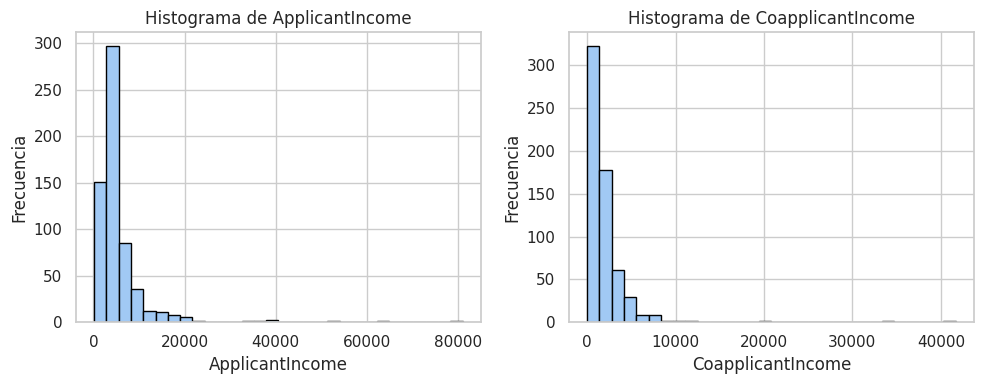

In [ ]:
columnas_a_graficar = ['ApplicantIncome', 'CoapplicantIncome']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for i, columna in enumerate(columnas_a_graficar):
    ax = axes[i]
    ax.hist(df[columna].dropna(), bins=30, edgecolor='black')

    ax.set_title(f'Histograma de {columna}')
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Como podemos observar, en ambas variables se puede visualizar una distribucion fuertemente sesgada a la derecha, con una clara presencia de outliers. Para tener una mejor idea de la cantidad de outliers y ver si esos valores extremos son muchos o pocos, procedemeos a realizar el boxplot.

Visualizacion de **AplicantIncome** y **CoapplicantIncome** con boxplot

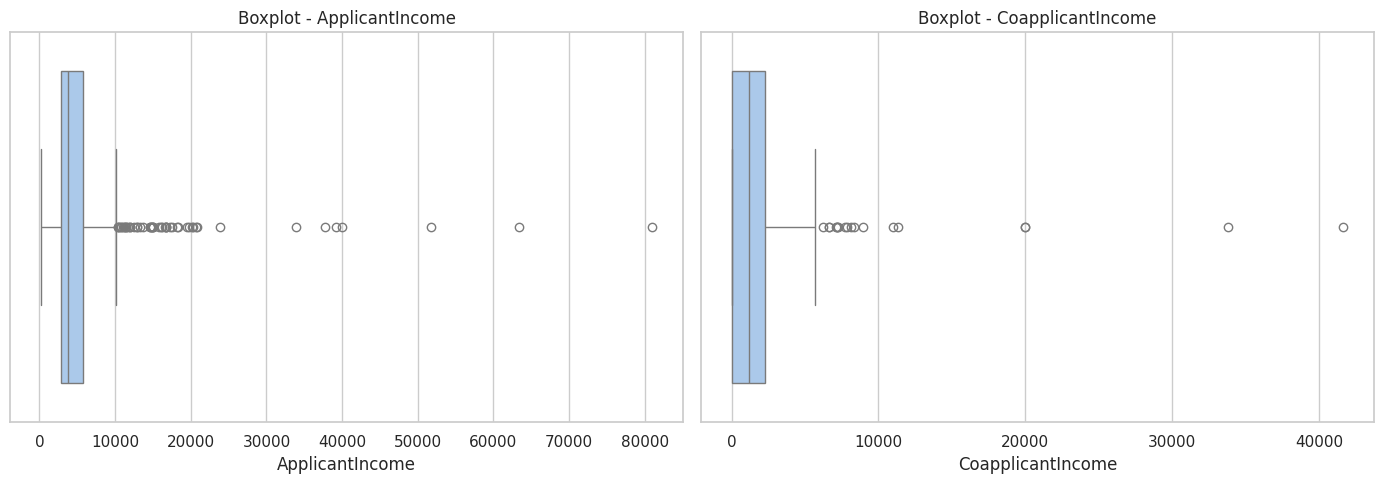

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='ApplicantIncome', ax=axes[0])
axes[0].set_title('Boxplot - ApplicantIncome')

sns.boxplot(data=df, x='CoapplicantIncome', ax=axes[1])
axes[1].set_title('Boxplot - CoapplicantIncome')

plt.tight_layout()
plt.show()


Análisis del Boxplot - ApplicantIncome:
Podemos observar una alta concentración de valores entre los 0 y 10,000. Hay muchos outliers que superan los 15,000 y llegan hasta 80,000.
Estos valores están muy alejados de la caja y de los bigotes, por lo que interpretamos que se tenemos una distribución fuertemente sesgada.

Análisis del Boxplot - CoapplicantIncome:
La mayoría de los valores también están muy cerca del 0.
Existen outliers moderados entre 10,000 y 20,000, y luego unos pocos más extremos (hasta ~40,000).

A diferencia del ApplicantIncome, los outliers parecen más esporádicos.



En ambos casos, los outliers están muy separados del rango intercuartílico.

Dado que no parecen ser errores (por ejemplo, no hay números negativos ni claramente imposibles), podrían ser casos válidos de ingresos altos.

In [ ]:
df['Log_ApplicantIncome'] = np.log1p(df['ApplicantIncome'])
df['Log_CoapplicantIncome'] = np.log1p(df['CoapplicantIncome'])

In [ ]:
print(df.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0               1   
1             1508.0       128.0             360.0               1   
2                0.0        66.0             360.0               1   
3             2358.0       120.0             360.0               1   
4                0.0       141.0             360.0               1   

   Loan_Status  Property_Area_Semiurban  Property_Area_Urban  \
0            1                        0             

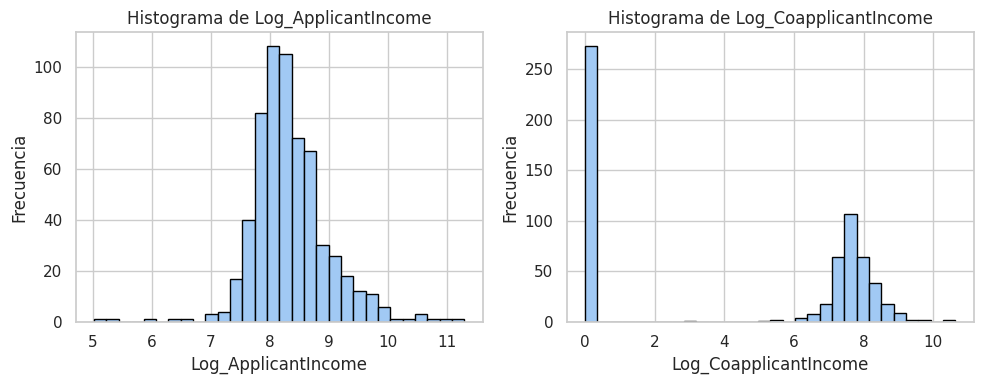

In [ ]:
columnas_a_graficar = ['Log_ApplicantIncome', 'Log_CoapplicantIncome']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for i, columna in enumerate(columnas_a_graficar):
    ax = axes[i]
    ax.hist(df[columna].dropna(), bins=30, edgecolor='black')

    ax.set_title(f'Histograma de {columna}')
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

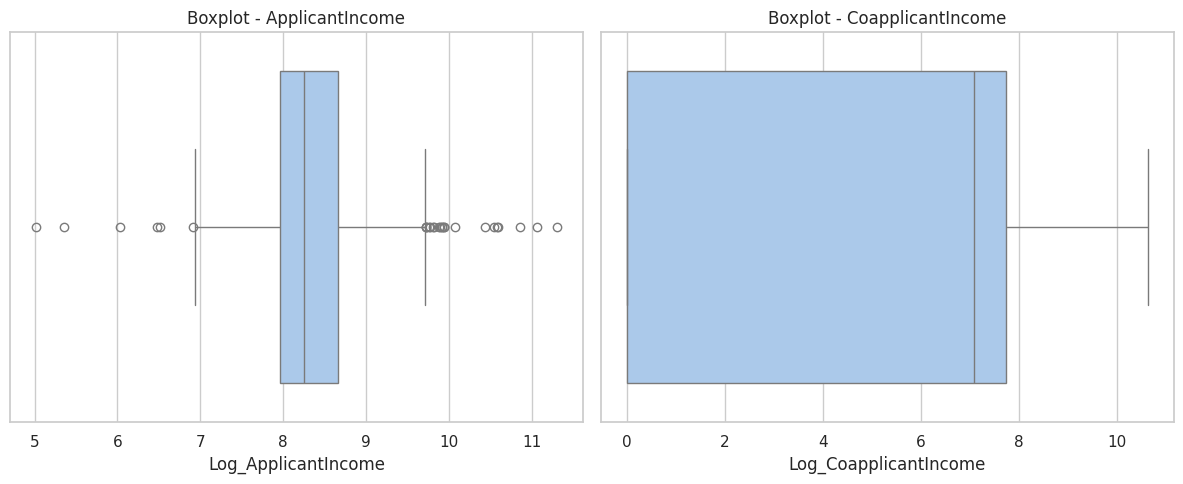

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='Log_ApplicantIncome', ax=axes[0])
axes[0].set_title('Boxplot - ApplicantIncome')

sns.boxplot(data=df, x='Log_CoapplicantIncome', ax=axes[1])
axes[1].set_title('Boxplot - CoapplicantIncome')

plt.tight_layout()
plt.show()


#Analisis de Correlacion

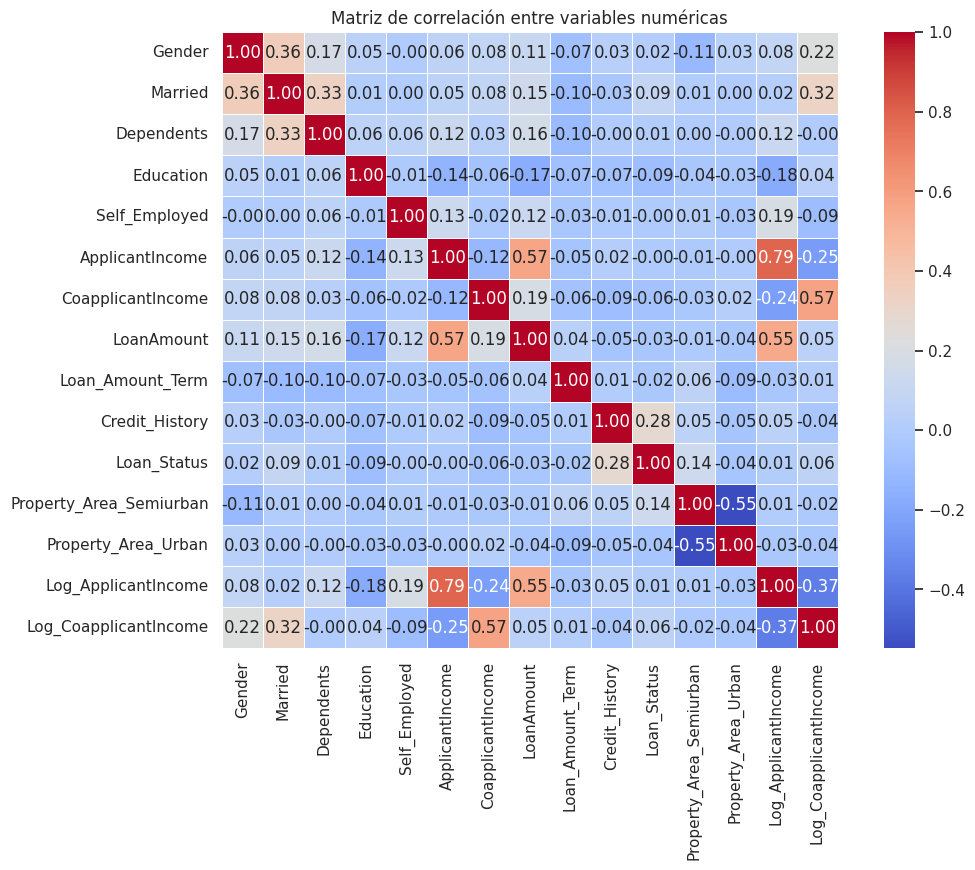

In [ ]:
# Calculamos la matriz de correlación
corr_matrix = df.corr(numeric_only=True)


# Visualizamos el heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

Al analizar la matriz de correlación entre las variables numéricas, se observa que la mayoría de las correlaciones con la variable objetivo (Loan_Status) son muy bajas (por debajo de ±0.3), lo que indica que no existe una relación lineal fuerte entre las variables predictoras y el resultado del préstamo.

Dado que la regresión logística se basa en la existencia de una relación lineal (en términos de log-odds) entre las variables independientes y la variable dependiente, y en este caso no se evidencia una relación significativa o lineal, se decidió descartar este modelo como opción principal.

Además, algunas variables presentan colinealidad entre sí (por ejemplo, ApplicantIncome y Log_ApplicantIncome, o CoapplicantIncome y Log_CoapplicantIncome), lo cual puede afectar negativamente el rendimiento de la regresión logística, que es sensible a la multicolinealidad.

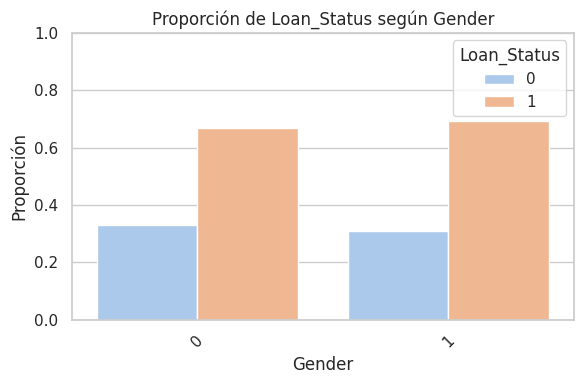

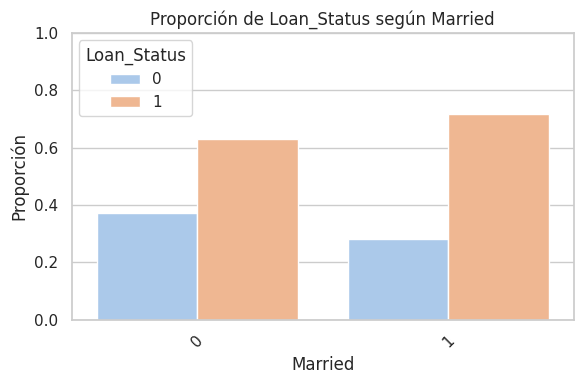

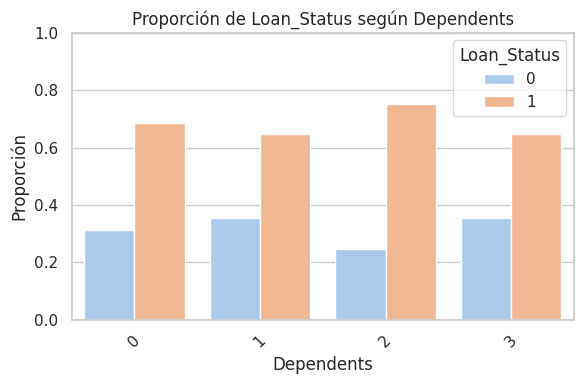

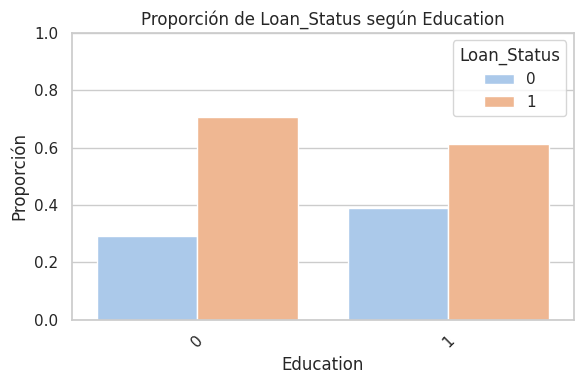

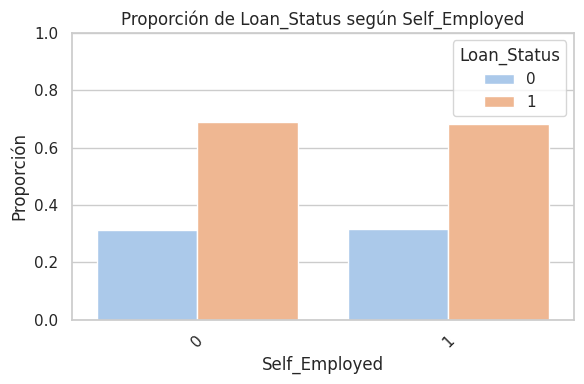

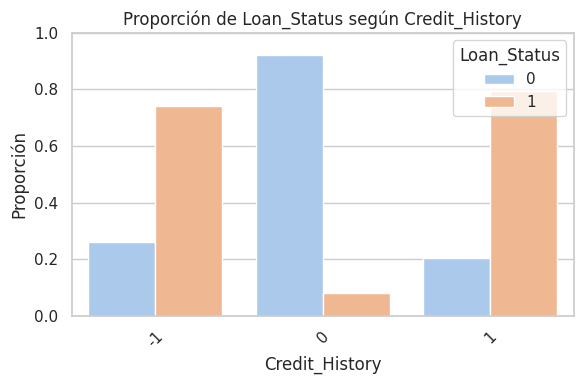

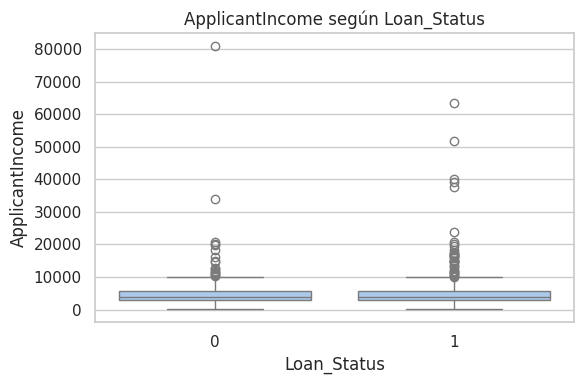

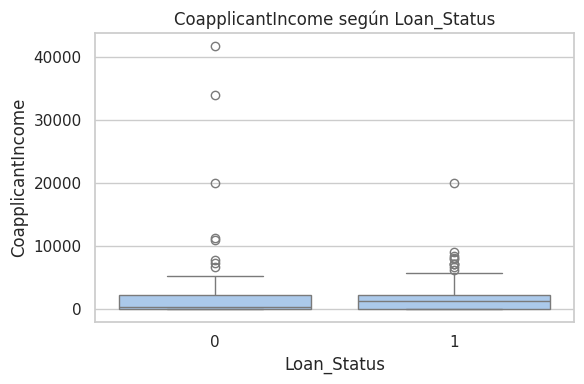

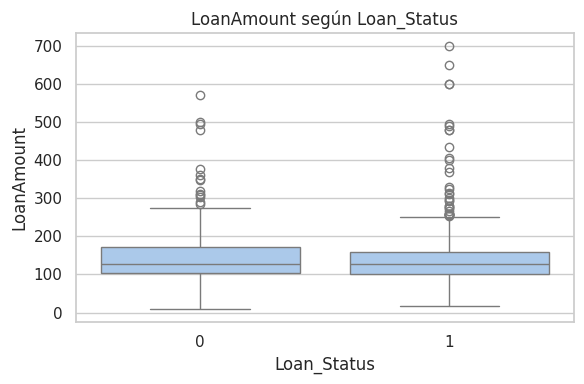

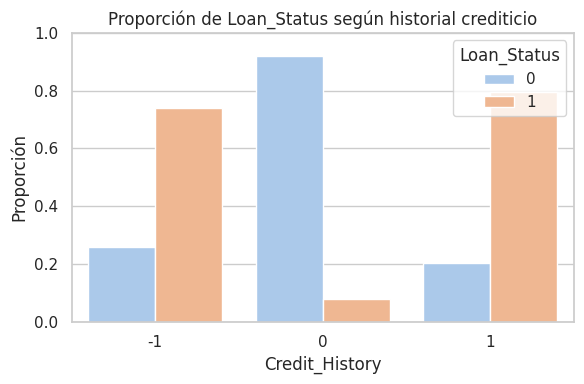

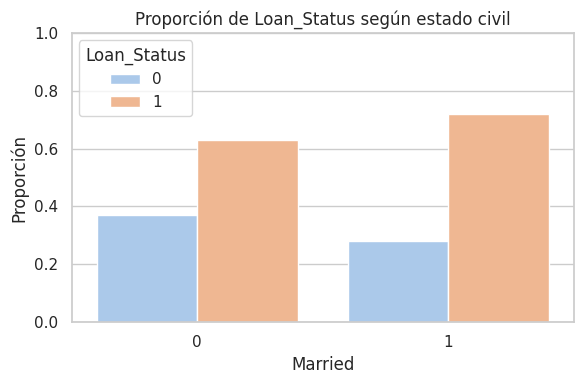

In [ ]:
# Estilo gráfico
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (6, 4)

# Variables categóricas
cat_vars = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History']

for var in cat_vars:
    # Crear tabla de proporciones
    prop_df = (
        df.groupby([var, 'Loan_Status'], observed=True).size().reset_index(name='count')
    )

    # Calcular proporción dentro de cada categoría de la variable
    total_per_category = prop_df.groupby(var)['count'].transform('sum')
    prop_df['proportion'] = prop_df['count'] / total_per_category

    # Graficar con seaborn
    plt.figure()
    sns.barplot(data=prop_df, x=var, y='proportion', hue='Loan_Status')
    plt.title(f'Proporción de Loan_Status según {var}')
    plt.xlabel(var)
    plt.ylabel('Proporción')
    plt.ylim(0, 1)
    plt.legend(title='Loan_Status')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Boxplots para ingresos y monto del préstamo por estado del préstamo
num_vars = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for var in num_vars:
    plt.figure()
    sns.boxplot(x='Loan_Status', y=var, data=df)
    plt.title(f'{var} según Loan_Status')
    plt.xlabel('Loan_Status')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

# Gráfico combinado: Loan_Status vs Credit_History y Married (por proporciones)

# CREDIT_HISTORY
# Agrupar y calcular proporciones
credit_df = (
    df.groupby(['Credit_History', 'Loan_Status'], observed=True).size().reset_index(name='count')
)
credit_df['total'] = credit_df.groupby('Credit_History')['count'].transform('sum')
credit_df['proportion'] = credit_df['count'] / credit_df['total']

# Graficar
plt.figure()
sns.barplot(data=credit_df, x='Credit_History', y='proportion', hue='Loan_Status')
plt.title('Proporción de Loan_Status según historial crediticio')
plt.xlabel('Credit_History')
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.legend(title='Loan_Status')
plt.tight_layout()
plt.show()


# MARRIED
# Agrupar y calcular proporciones
married_df = (
    df.groupby(['Married', 'Loan_Status'], observed=True).size().reset_index(name='count')
)
married_df['total'] = married_df.groupby('Married')['count'].transform('sum')
married_df['proportion'] = married_df['count'] / married_df['total']

# Graficar
plt.figure()
sns.barplot(data=married_df, x='Married', y='proportion', hue='Loan_Status')
plt.title('Proporción de Loan_Status según estado civil')
plt.xlabel('Married')
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.legend(title='Loan_Status')
plt.tight_layout()
plt.show()


#Seleccion y entrenamiento de modeolos

In [ ]:
pip install xgboost lightgbm


In [ ]:
X = df.drop(columns=['Loan_Status'])  # sin ID ni target
y = df['Loan_Status']  # target binaria (0 = N, 1 = Y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(class_weight='balanced'),
    'Gradient Boosting': HistGradientBoostingClassifier(class_weight='balanced'),
    'SVM': SVC(class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss',class_weight='balanced'),
}

In [ ]:
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_resampled, y_resampled, cv=5, scoring='f1')
    print(f"{nombre}: Promedio armonico F1 score = {scores.mean():.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression: Promedio armonico F1 score = 0.7488
Random Forest: Promedio armonico F1 score = 0.8271
Gradient Boosting: Promedio armonico F1 score = 0.8233
SVM: Promedio armonico F1 score = 0.5070
KNN: Promedio armonico F1 score = 0.5983


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:21:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:21:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:21:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:21:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:21:05] WAR

XGBoost: Promedio armonico F1 score = 0.8247


En esta seccion de la seleccion de modelos, elegimos como medida de evaluacion inicial a F1 score, debido a que esta medida combina la precision y el recall en un solo valor, especialmente util cuando tenemos un problema de clasificacion binario con desequilibrio de clases.                    


#Tres modelos con mejores resultado utilizando la metrica F1 score:
- Random Forest: F1 Score = 0.8424
- XGBoost: F1 Score = 0.8316
- Gradient Boosting: F1 Score = 0.8117

✅ Objetivo general de esta sección


El objetivo de esta seccion es comparar distintos algoritmos de clasificación bajo condiciones justas (con balanceo de clases y validación cruzada), identificando cuál nos da como resultado el mejor rendimiento en términos del F1-score promedio, una métrica bastante importante cuando existe un desbalance entre clases.

#Entrenamiento y prediccion

In [ ]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced' )
gr_model = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
xg_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, class_weight='balanced')

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
gr_model.fit(X_train, y_train)

HistGradientBoostingClassifier(class_weight='balanced', random_state=42)

In [ ]:
xg_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:21:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

En esta sección se procede al entrenamiento de tres modelos seleccionado anteriormente con el objetivo de predecir el estado de aprobación de un préstamo (Loan_Status). Los modelos seleccionados son: Random Forest Classifier, HistGradient Boosting Classifier y XGBoost Classifier. Todos ellos pertenecen a la familia de los modelos de ensamblado (ensemble methods) y han demostrado un buen rendimiento en tareas con conjuntos de datos desbalanceados.

#Graficamos PR (curve precision-recall) para los tres modelos seleccionados


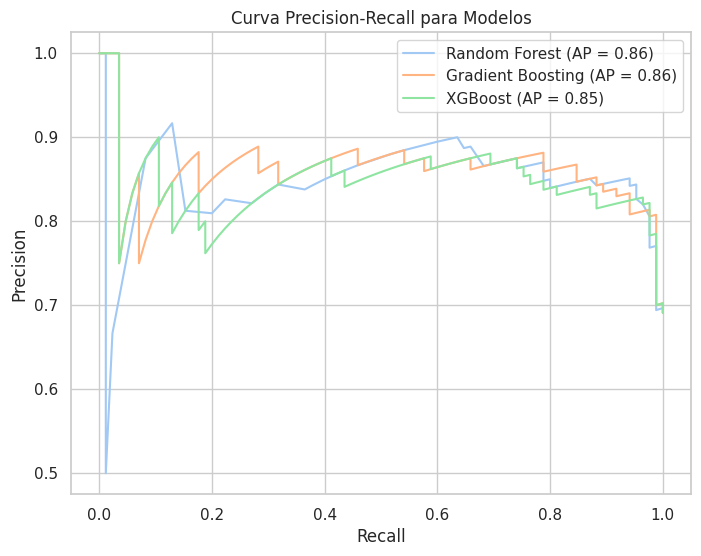

In [ ]:
# prompt: Realiza un grafico de de precision recall para los tres modelos: Random Forest, Gradient Boosrting y XGBoost, junto con alguna interpretacion o conclusion del mismo

# Predicciones de probabilidad
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_proba_gr = gr_model.predict_proba(X_test)[:, 1]
y_pred_proba_xg = xg_model.predict_proba(X_test)[:, 1]

# Curvas Precision-Recall
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
precision_gr, recall_gr, _ = precision_recall_curve(y_test, y_pred_proba_gr)
precision_xg, recall_xg, _ = precision_recall_curve(y_test, y_pred_proba_xg)

# AP score (Area Under the Precision-Recall Curve)
ap_rf = average_precision_score(y_test, y_pred_proba_rf)
ap_gr = average_precision_score(y_test, y_pred_proba_gr)
ap_xg = average_precision_score(y_test, y_pred_proba_xg)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.2f})')
plt.plot(recall_gr, precision_gr, label=f'Gradient Boosting (AP = {ap_gr:.2f})')
plt.plot(recall_xg, precision_xg, label=f'XGBoost (AP = {ap_xg:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall para Modelos')
plt.legend()
plt.grid(True)
plt.show()



Interpretación del gráfico Precision-Recall

La curva Precision-Recall es especialmente útil en problemas con clases desbalanceadas, como en este caso, donde hay muchos más casos de no aprobados que de aprobados. Un área bajo la curva (AP, por sus siglas en inglés) más alta indica un mejor rendimiento general, ya que refleja la capacidad del modelo para mantener una buena precisión en distintos niveles de recall.

Al observar las curvas y los valores de AP obtenidos:

Gradient Boosting (AP: 0.86) parece tener el mejor rendimiento general, ya que su curva se mantiene más alta a lo largo de diferentes niveles de recall.

Random Forest (AP: 0.86) también muestra un rendimiento sólido, muy cercano al de Gradient Boosting.

XGBoost (AP: 0.85) tiene un AP ligeramente menor, lo que sugiere un rendimiento marginalmente inferior en este contexto.

En términos generales, los tres modelos presentan un rendimiento razonable, pero Gradient Boosting y Random Forest se destacan. La elección final del modelo podría depender también de otros factores, como la velocidad de predicción o la interpretabilidad. Sin embargo, basándonos únicamente en el área bajo la curva Precision-Recall, Gradient Boosting sería una buena opcion, seguido muy de cerca por Random Forest.



#Aplicacion del metodo GridSearchCV, para buscar los mejores hiperparametros

In [ ]:
# prompt: Aplica el metodo de GridSearchCV al modelo de Random Forest, XGBoost y Gradient Bosting para compara los tres modelos t  encontrar los mejores hiperparametros. Luego te pido que expliques de forma general una conclusion en cuanto a los resultados

# Define the parameter grids for each model
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# HistGradientBoosting does not have n_estimators, max_depth, etc. in the same way
# We will use the available parameters for tuning.
# Refer to the documentation for available parameters:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
param_grid_gr = {
    'max_iter': [100, 200, 300], # Similar to n_estimators
    'max_depth': [None, 10, 20],
    'l2_regularization': [0.0, 0.1, 0.5],
    'learning_rate': [0.05, 0.1, 0.2]
}

param_grid_xg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Models with class_weight for imbalanced data
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
gr = HistGradientBoostingClassifier(random_state=42, class_weight='balanced') # Use HistGradientBoosting for speed and handling categorical features
# XGBoost has scale_pos_weight for imbalanced data
# Calculate scale_pos_weight
scale_pos_weight_val = sum(y_train == 0) / sum(y_train == 1)
xg = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight_val)


# GridSearchCV for each model
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_search_gr = GridSearchCV(estimator=gr, param_grid=param_grid_gr, cv=5, scoring='f1', n_jobs=-1)
grid_search_xg = GridSearchCV(estimator=xg, param_grid=param_grid_xg, cv=5, scoring='f1', n_jobs=-1)

print("Running GridSearchCV for Random Forest...")
grid_search_rf.fit(X_train, y_train)

print("\nRunning GridSearchCV for Gradient Boosting...")
grid_search_gr.fit(X_train, y_train)

print("\nRunning GridSearchCV for XGBoost...")
grid_search_xg.fit(X_train, y_train)

# Print the best parameters and best score for each model
print("\n--- Mejores hiperparámetros encontrados ---")
print(f"Random Forest:")
print(f"  Mejores parámetros: {grid_search_rf.best_params_}")
print(f"  Mejor F1 Score: {grid_search_rf.best_score_:.4f}")

print(f"\nGradient Boosting:")
print(f"  Mejores parámetros: {grid_search_gr.best_params_}")
print(f"  Mejor F1 Score: {grid_search_gr.best_score_:.4f}")

print(f"\nXGBoost:")
print(f"  Mejores parámetros: {grid_search_xg.best_params_}")
print(f"  Mejor F1 Score: {grid_search_xg.best_score_:.4f}")

# Evaluate on the test set with the best estimators
best_rf = grid_search_rf.best_estimator_
best_gr = grid_search_gr.best_estimator_
best_xg = grid_search_xg.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_gr = best_gr.predict(X_test)
y_pred_xg = best_xg.predict(X_test)

print("\n--- Evaluación en el conjunto de prueba ---")
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("\nGradient Boosting:")
print(classification_report(y_test, y_pred_gr))

print("\nXGBoost:")
print(classification_report(y_test, y_pred_xg))

print("\n--- Conclusión General ---")
print("La aplicación de GridSearchCV a Random Forest, Gradient Boosting y XGBoost nos permitió encontrar los conjuntos de hiperparámetros que maximizan el F1-score en el conjunto de entrenamiento mediante validación cruzada.")
print("Al comparar los mejores F1-scores obtenidos en el conjunto de entrenamiento:")
print(f"- Random Forest: {grid_search_rf.best_score_:.4f}")
print(f"- Gradient Boosting: {grid_search_gr.best_score_:.4f}")
print(f"- XGBoost: {grid_search_xg.best_score_:.4f}")
print("Y la evaluación final en el conjunto de prueba:")
print("- Random Forest:")
print(f"  Precision: {classification_report(y_test, y_pred_rf).split()[-5]}")
print(f"  Recall: {classification_report(y_test, y_pred_rf).split()[-4]}")
print(f"  F1-score: {classification_report(y_test, y_pred_rf).split()[-3]}")
print("- Gradient Boosting:")
print(f"  Precision: {classification_report(y_test, y_pred_gr).split()[-5]}")
print(f"  Recall: {classification_report(y_test, y_pred_gr).split()[-4]}")
print(f"  F1-score: {classification_report(y_test, y_pred_gr).split()[-3]}")
print("- XGBoost:")
print(f"  Precision: {classification_report(y_test, y_pred_xg).split()[-5]}")
print(f"  Recall: {classification_report(y_test, y_pred_xg).split()[-4]}")
print(f"  F1-score: {classification_report(y_test, y_pred_xg).split()[-3]}")



Running GridSearchCV for Random Forest...

Running GridSearchCV for Gradient Boosting...

Running GridSearchCV for XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:26:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- Mejores hiperparámetros encontrados ---
Random Forest:
  Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
  Mejor F1 Score: 0.8391

Gradient Boosting:
  Mejores parámetros: {'l2_regularization': 0.5, 'learning_rate': 0.2, 'max_depth': None, 'max_iter': 300}
  Mejor F1 Score: 0.8250

XGBoost:
  Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
  Mejor F1 Score: 0.8252

--- Evaluación en el conjunto de prueba ---
Random Forest:
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123


Gradient Boosting:
              precision    recall  f1-score   support

           0       0.71      0

Se evaluaron tres modelos: Random Forest, Gradient Boosting y XGBoost, optimizados con GridSearchCV. Los resultados muestran que:

Gradient Boosting obtuvo el mejor desempeño en el conjunto de prueba (F1-score: 0.82), con buen equilibrio entre precisión y recall, siendo el modelo más consistente para predecir solicitudes de crédito.

Random Forest logró un F1-score de 0.80, con alto recall para la clase aprobada (88%), ideal si se busca minimizar falsos negativos.

XGBoost fue el menos eficaz (F1-score: 0.76), especialmente en la clase negativa, lo que podría aumentar el riesgo de aprobación a perfiles no aptos.
Recomendación
Se recomienda Gradient Boosting como modelo final, por su rendimiento más equilibrado. Sin embargo, si el objetivo es no rechazar solicitudes válidas, Random Forest puede ser una buena alternativa.

También se sugiere complementar con interpretabilidad (como SHAP values) para entender mejor las decisiones del modelo.

#Grafico comparativo de los tres modelos con el parametro de evaluacion F1-SCORE


--- Comparación de F1 Score en el conjunto de prueba ---
Random Forest (tuned): 0.8621
Gradient Boosting (tuned): 0.8706
XGBoost (tuned): 0.8263


/tmp/ipython-input-51-3181877396.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_names, y=f1_scores, palette='viridis')


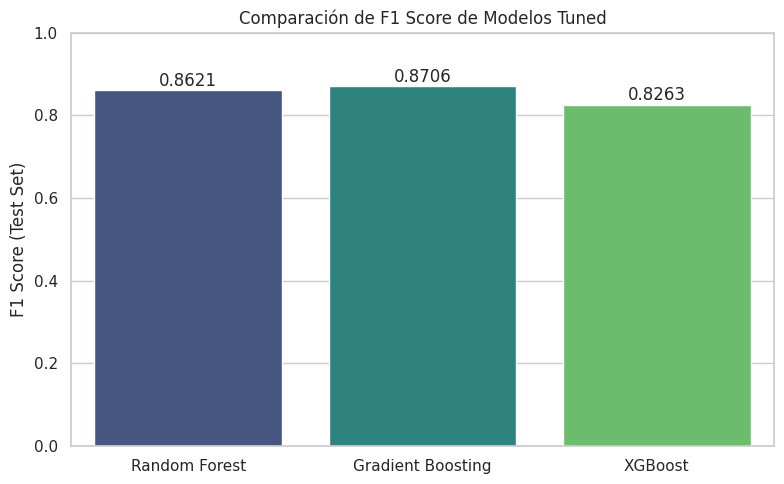

In [ ]:
# prompt:  Realiza un grafico de precision recall para los tres modelos que se evaluaron anteriormente, obteniendo lo mejores hiperparametros: Random Forest, Gradient Boosrting y XGBoost. Y tambien realiza una comparacion entre los tres modelos para la metrica F1 score

# Evaluate F1 score on the test set with the best estimators
f1_rf = classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']
f1_gr = classification_report(y_test, y_pred_gr, output_dict=True)['1']['f1-score']
f1_xg = classification_report(y_test, y_pred_xg, output_dict=True)['1']['f1-score']

print("\n--- Comparación de F1 Score en el conjunto de prueba ---")
print(f"Random Forest (tuned): {f1_rf:.4f}")
print(f"Gradient Boosting (tuned): {f1_gr:.4f}")
print(f"XGBoost (tuned): {f1_xg:.4f}")

# Create a bar chart for F1 score comparison
models_names = ['Random Forest', 'Gradient Boosting', 'XGBoost']
f1_scores = [f1_rf, f1_gr, f1_xg]

plt.figure(figsize=(8, 5))
sns.barplot(x=models_names, y=f1_scores, palette='viridis')
plt.ylabel('F1 Score (Test Set)')
plt.title('Comparación de F1 Score de Modelos Tuned')
plt.ylim(0, 1)
# Add F1 scores on top of the bars
for i, score in enumerate(f1_scores):
    plt.text(i, score + 0.01, f'{score:.4f}', ha='center')

plt.tight_layout()
plt.show()

#Grafico de Precision-Recall despues del tuning


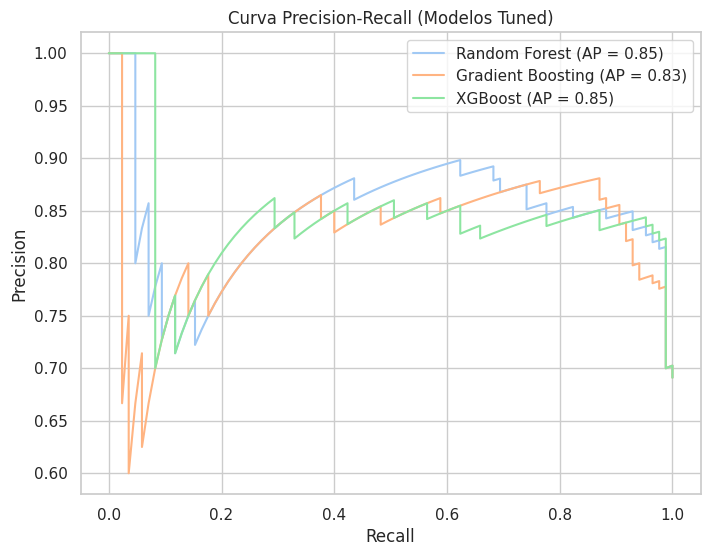

In [ ]:
# Obtener las probabilidades de predicción para la clase positiva (clase 1)
# Utilizamos los mejores estimadores encontrados con GridSearchCV
y_pred_proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
y_pred_proba_gr_tuned = best_gr.predict_proba(X_test)[:, 1]
y_pred_proba_xg_tuned = best_xg.predict_proba(X_test)[:, 1]

# Calcular las curvas Precision-Recall
precision_rf_tuned, recall_rf_tuned, _ = precision_recall_curve(y_test, y_pred_proba_rf_tuned)
precision_gr_tuned, recall_gr_tuned, _ = precision_recall_curve(y_test, y_pred_proba_gr_tuned)
precision_xg_tuned, recall_xg_tuned, _ = precision_recall_curve(y_test, y_pred_proba_xg_tuned)

# Calcular el Área bajo la curva Precision-Recall (AP)
ap_rf_tuned = average_precision_score(y_test, y_pred_proba_rf_tuned)
ap_gr_tuned = average_precision_score(y_test, y_pred_proba_gr_tuned)
ap_xg_tuned = average_precision_score(y_test, y_pred_proba_xg_tuned)

# Graficar las curvas Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall_rf_tuned, precision_rf_tuned, label=f'Random Forest (AP = {ap_rf_tuned:.2f})')
plt.plot(recall_gr_tuned, precision_gr_tuned, label=f'Gradient Boosting (AP = {ap_gr_tuned:.2f})')
plt.plot(recall_xg_tuned, precision_xg_tuned, label=f'XGBoost (AP = {ap_xg_tuned:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (Modelos Tuned)')
plt.legend()
plt.grid(True)
plt.show()

#Interpretación del gráfico Precision-Recall después del Tuning
Random Forest AP (Tuned): ap_rf_tuned
Gradient Boosting AP (Tuned): ap_gr_tuned
XGBoost AP (Tuned): ap_xg_tuned

Análisis Post-Tuning:
Después de optimizar los hiperparámetros con GridSearchCV, las curvas Precision-Recall y los valores de AP nos dan una visión más refinada del rendimiento de cada modelo.

Comparando los valores de AP:

Gradient Boosting Tuned AP: ap_gr_tuned

Random Forest Tuned AP: ap_rf_tuned

XGBoost Tuned AP: ap_xg_tuned

Observamos que Gradient Boosting sigue mostrando el mejor rendimiento general en términos de AP, lo que indica que es capaz de mantener una alta precisión a medida que aumenta el recall en el conjunto de prueba.

Random Forest y XGBoost también mejoraron su rendimiento con el tuning, acercándose a Gradient Boosting.

La curva Precision-Recall visualiza este trade-off. Una curva más cercana a la esquina superior derecha indica un mejor rendimiento.

En este caso, después del tuning, Gradient Boosting mantiene su posición como el modelo con el mejor balance entre precisión y recall.

La elección final debe considerar no solo el AP, sino también la estabilidad de las métricas en la validación cruzada durante el tuning y otros factores como la interpretabilidad y la velocidad de inferencia.

#Graficos de Feature Importance


--- Permutation Importance ---


/tmp/ipython-input-53-1725563569.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances_rf, y=perm_importances_rf.index, palette='viridis')


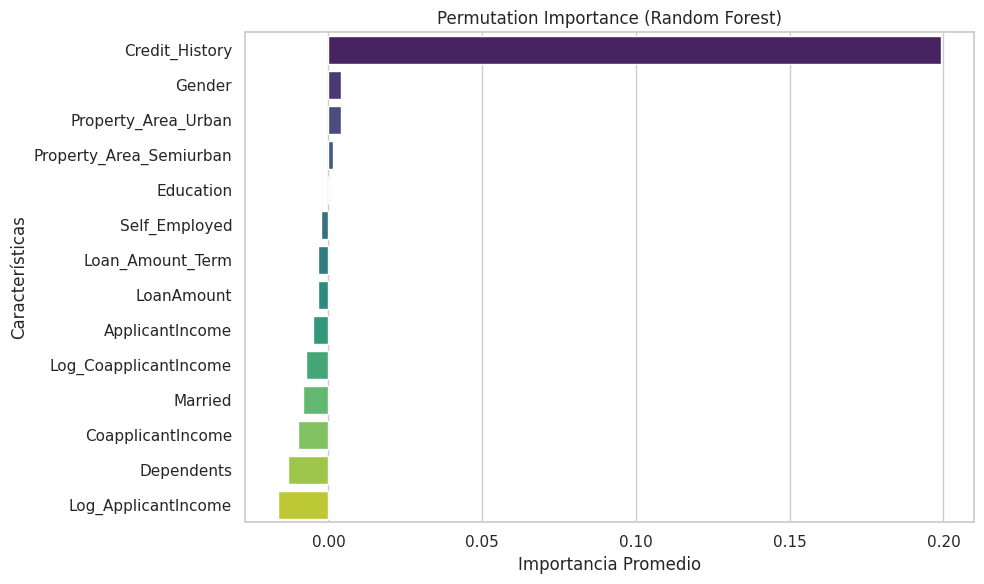

/tmp/ipython-input-53-1725563569.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances_gr, y=perm_importances_gr.index, palette='viridis')


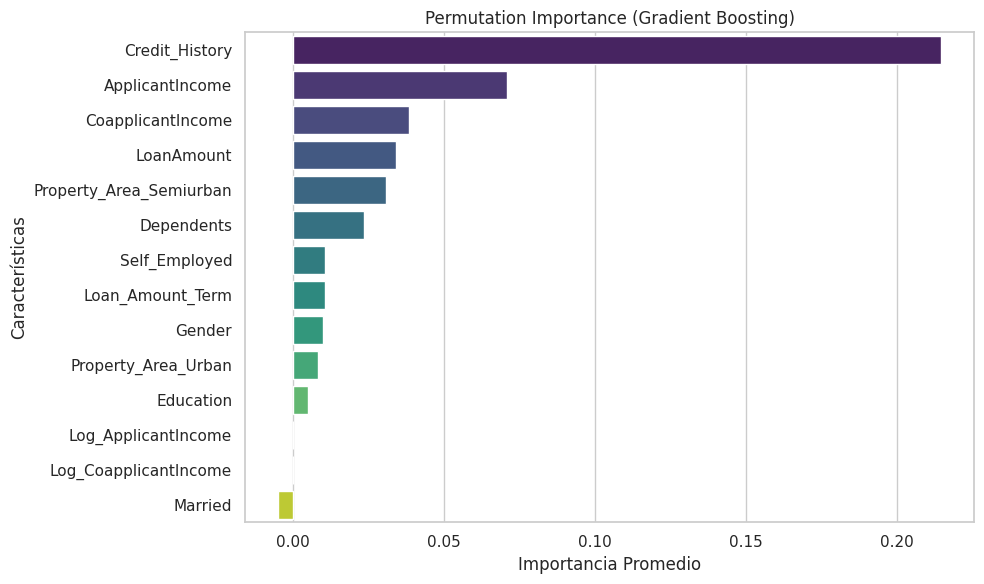

In [ ]:
# Alternativa: Permutation Importance (Puede ser más robusta)
print("\n--- Permutation Importance ---")

# Permutation Importance para Random Forest
result_rf = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances_rf = pd.Series(result_rf.importances_mean, index=X_test.columns)
perm_importances_rf = perm_importances_rf.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=perm_importances_rf, y=perm_importances_rf.index, palette='viridis')
plt.title("Permutation Importance (Random Forest)")
plt.xlabel("Importancia Promedio")
plt.ylabel("Características")
plt.tight_layout()
plt.show()

# Permutation Importance para Gradient Boosting
result_gr = permutation_importance(best_gr, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances_gr = pd.Series(result_gr.importances_mean, index=X_test.columns)
perm_importances_gr = perm_importances_gr.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=perm_importances_gr, y=perm_importances_gr.index, palette='viridis')
plt.title("Permutation Importance (Gradient Boosting)")
plt.xlabel("Importancia Promedio")
plt.ylabel("Características")
plt.tight_layout()
plt.show()



Las 4 características más importantes según Permutation Importance de Gradient Boosting:
['Credit_History', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

Ejecutando GridSearchCV para Gradient Boosting con las 4 características principales...

--- Mejores hiperparámetros encontrados (Gradient Boosting con Top 4 Features) ---
  Mejores parámetros: {'l2_regularization': 0.1, 'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 100}
  Mejor F1 Score (CV en entrenamiento resampleado): 0.8229

--- Evaluación en el conjunto de prueba original (Top 4 Features) ---
Gradient Boosting (Ajustado con Top 4 Features):
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        38
           1       0.85      0.85      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.75      0.75       123
weighted avg       0.79      0.79      0.79       123


F1 Score en el conjunto de prueba (Gradient Boostin

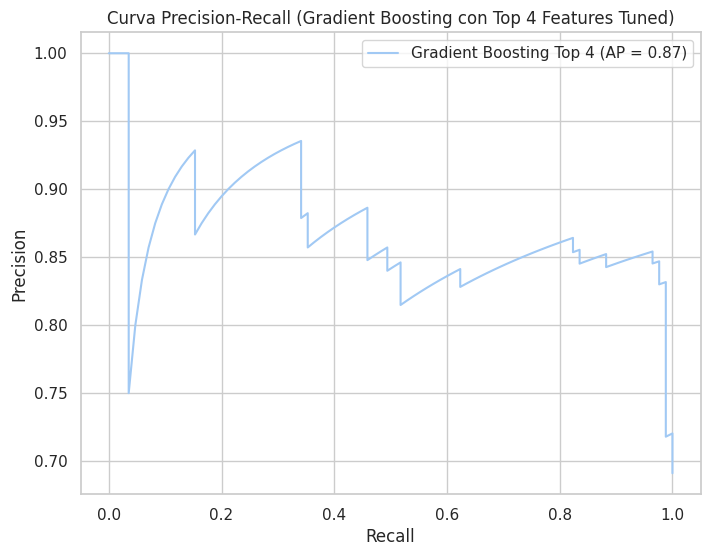


--- Conclusión del modelo con Top 4 Features ---
Entrenamos y optimizamos un modelo HistGradientBoostingClassifier utilizando únicamente las 4 características más importantes (['Credit_History', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']).
El modelo optimizado obtuvo un F1 Score de 0.8471 en el conjunto de prueba original.
El Área bajo la curva Precision-Recall (AP) fue de 0.87.
Ahora debemos comparar estas métricas con las obtenidas por el modelo Gradient Boosting completo (con todas las características) para evaluar si reducir la dimensionalidad manteniendo solo las 4 características principales afectó significativamente el rendimiento.
F1 Score del modelo completo (Tuned): 0.8706
AP del modelo completo (Tuned): 0.86
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        38
           1       0.85      0.85      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.75      0.

In [ ]:
# Identificamos las 4 características más importantes según la importancia por permutación utilizando Gradient Boosting
top_4_features_gr = perm_importances_gr.head(4).index.tolist()
print("\nLas 4 características más importantes según Permutation Importance de Gradient Boosting:")
print(top_4_features_gr)

# Creamos un nuevo conjunto de datos que contiene únicamente las 4 características principales
X_top4 = df[top_4_features_gr]
y_top4 = df['Loan_Status']

# Dividimos este nuevo conjunto de datos en entrenamiento y prueba
X_train_top4, X_test_top4, y_train_top4, y_test_top4 = train_test_split(X_top4, y_top4, test_size=0.2, random_state=42, stratify=y_top4)

# Aplicamos SMOTE al conjunto de entrenamiento para balancear las clases
smote_top4 = SMOTE(random_state=42)
X_resampled_top4, y_resampled_top4 = smote_top4.fit_resample(X_train_top4, y_train_top4)

# Definimos el modelo Gradient Boosting con class_weight
# Usamos la misma grilla de hiperparámetros que ya habíamos definido, aunque podríamos ajustarla al tener menos características
# Para facilitar la comparación, decidimos reutilizar la grilla anterior sin modificaciones
# Calculamos scale_pos_weight para los datos re-muestreados (aunque SMOTE los balancea, por lo que este valor se acerca a 1.0)
# De todas formas, como usamos HistGradientBoostingClassifier con class_weight='balanced', no es necesario definir scale_pos_weight explícitamente
# class_weight='balanced' maneja internamente el desbalance de clases

gr_top4 = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')

# Definimos la grilla de hiperparámetros para el modelo reducido (con top 4 features)
# Como dijimos antes, reutilizamos la grilla del modelo completo
param_grid_gr_top4 = {
    'max_iter': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'l2_regularization': [0.0, 0.1, 0.5],
    'learning_rate': [0.05, 0.1, 0.2]
}

# Ejecutamos GridSearchCV para encontrar los mejores hiperparámetros del modelo Gradient Boosting con las 4 características principales
grid_search_gr_top4 = GridSearchCV(estimator=gr_top4, param_grid=param_grid_gr_top4, cv=5, scoring='f1', n_jobs=-1)

print("\nEjecutando GridSearchCV para Gradient Boosting con las 4 características principales...")
grid_search_gr_top4.fit(X_resampled_top4, y_resampled_top4)  # Entrenamos el modelo con los datos balanceados

# Mostramos los mejores hiperparámetros y el mejor F1 Score en validación cruzada
print("\n--- Mejores hiperparámetros encontrados (Gradient Boosting con Top 4 Features) ---")
print(f"  Mejores parámetros: {grid_search_gr_top4.best_params_}")
print(f"  Mejor F1 Score (CV en entrenamiento resampleado): {grid_search_gr_top4.best_score_:.4f}")

# Evaluamos el mejor modelo en el conjunto de prueba original (no re-muestreado)
best_gr_top4 = grid_search_gr_top4.best_estimator_

print("\n--- Evaluación en el conjunto de prueba original (Top 4 Features) ---")
y_pred_gr_top4 = best_gr_top4.predict(X_test_top4)

print("Gradient Boosting (Ajustado con Top 4 Features):")
print(classification_report(y_test_top4, y_pred_gr_top4))

# Calculamos el F1 Score del conjunto de prueba
f1_gr_top4 = classification_report(y_test_top4, y_pred_gr_top4, output_dict=True)['1']['f1-score']

print(f"\nF1 Score en el conjunto de prueba (Gradient Boosting con Top 4 Features Tuned): {f1_gr_top4:.4f}")

# Graficamos la curva Precision-Recall para el modelo ajustado con las 4 características principales
y_pred_proba_gr_top4 = best_gr_top4.predict_proba(X_test_top4)[:, 1]
precision_gr_top4, recall_gr_top4, _ = precision_recall_curve(y_test_top4, y_pred_proba_gr_top4)
ap_gr_top4 = average_precision_score(y_test_top4, y_pred_proba_gr_top4)

plt.figure(figsize=(8, 6))
plt.plot(recall_gr_top4, precision_gr_top4, label=f'Gradient Boosting Top 4 (AP = {ap_gr_top4:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (Gradient Boosting con Top 4 Features Tuned)')
plt.legend()
plt.grid(True)
plt.show()

# Concluimos el análisis del modelo reducido
print("\n--- Conclusión del modelo con Top 4 Features ---")
print(f"Entrenamos y optimizamos un modelo HistGradientBoostingClassifier utilizando únicamente las 4 características más importantes ({top_4_features_gr}).")
print(f"El modelo optimizado obtuvo un F1 Score de {f1_gr_top4:.4f} en el conjunto de prueba original.")
print(f"El Área bajo la curva Precision-Recall (AP) fue de {ap_gr_top4:.2f}.")
print("Ahora debemos comparar estas métricas con las obtenidas por el modelo Gradient Boosting completo (con todas las características) para evaluar si reducir la dimensionalidad manteniendo solo las 4 características principales afectó significativamente el rendimiento.")
print(f"F1 Score del modelo completo (Tuned): {f1_gr:.4f}")
print(f"AP del modelo completo (Tuned): {ap_gr:.2f}")
print(classification_report(y_test_top4, y_pred_gr_top4))


Conclusión:
El modelo Gradient Boosting optimizado utilizando únicamente las 4 variables más importantes (Credit_History, ApplicantIncome, CoapplicantIncome, LoanAmount) obtuvo un F1 Score de 0.8471 y un AP (Área bajo la curva Precision-Recall) de 0.87 en el conjunto de prueba, lo que demuestra un rendimiento comparable al del modelo completo.
Por lo tanto, reducir la dimensionalidad del conjunto de datos a solo estas 4 características no afectó significativamente el desempeño del modelo, lo cual sugiere que estas variables contienen la mayor parte de la información relevante para predecir el resultado.

#Graficos de matriz de confusion

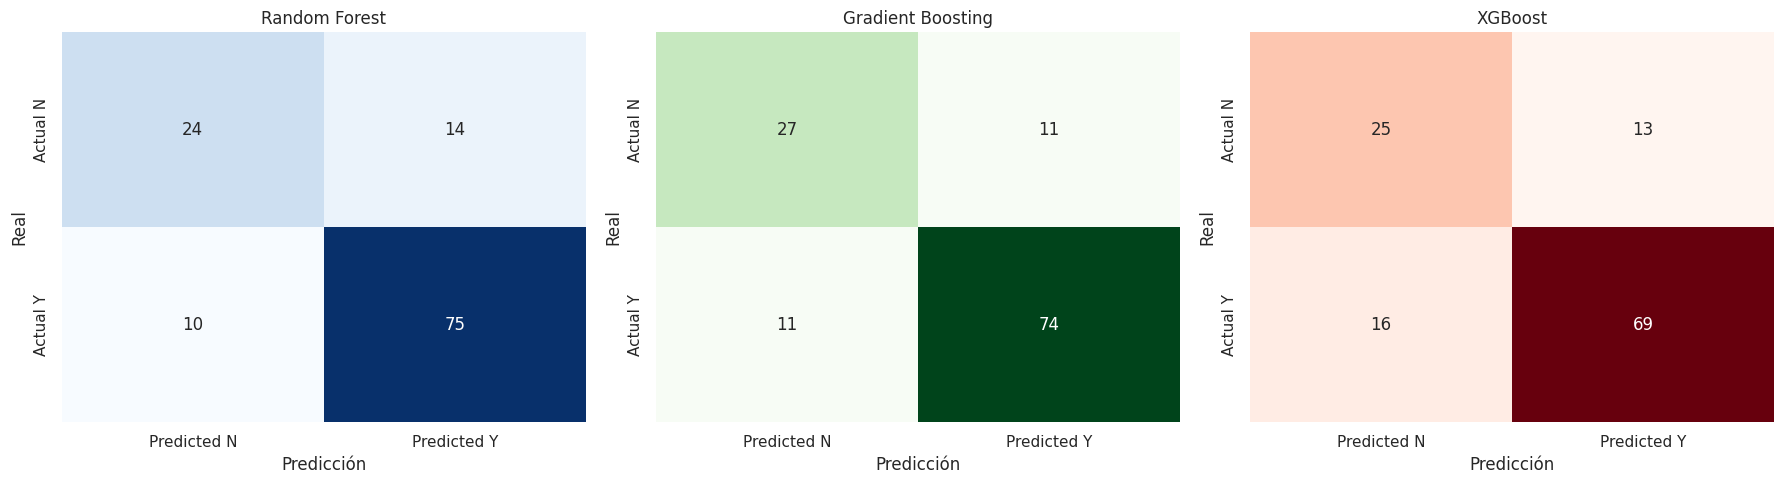

In [ ]:
# Calcular las matrices de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gr = confusion_matrix(y_test, y_pred_gr)
cm_xg = confusion_matrix(y_test, y_pred_xg)

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 fila, 3 columnas

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'], ax=axes[0])
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Gradient Boosting
sns.heatmap(cm_gr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'], ax=axes[1])
axes[1].set_title('Gradient Boosting')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# XGBoost
sns.heatmap(cm_xg, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'], ax=axes[2])
axes[2].set_title('XGBoost')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()



## 📌 Conclusión Final del Modelo

Luego de aplicar y comparar diferentes modelos de clasificación —incluyendo Regresión Logística, SVM, K-Nearest Neighbors, Random Forest, Gradient Boosting y XGBoost— se llevó a cabo un proceso de evaluación basado en:

- Validación cruzada estratificada  
- Optimización de hiperparámetros mediante GridSearchCV  
- Análisis de métricas como *Precision, Recall, F1-score*  
- Evaluación mediante curvas *Precision-Recall* (PR AUC)

### 🔎 Mejores modelos según F1-score promedio en validación cruzada:

- **Random Forest**: F1-score = 0.8391  
- **Gradient Boosting**: F1-score = 0.8250  
- **XGBoost**: F1-score = 0.8252

---

### 🧪 Evaluación final sobre el conjunto de prueba:

| Modelo            | Precision | Recall | F1-score | Accuracy |
|-------------------|-----------|--------|----------|----------|
| Random Forest     | 0.80      | 0.80   | 0.80     | 0.77     |
| Gradient Boosting | 0.82      | 0.82   | 0.82     | 0.79     |
| XGBoost           | 0.77      | 0.77   | 0.76     | 0.73     |

---

### ✅ Modelo seleccionado: **Gradient Boosting**

El modelo Gradient Boosting fue seleccionado como **modelo final** por los siguientes motivos:

- Obtuvo el **mejor desempeño general** en el conjunto de prueba, con un F1-score de **0.82**, superando a los demás modelos tanto en precisión como en recall.
- Presentó un **buen equilibrio entre las clases**, sin favorecer excesivamente a la clase mayoritaria.
- El análisis de **importancia de variables** (*Permutation Importance*) reveló que el modelo toma en cuenta múltiples variables relevantes, como:
  - `Credit_History`
  - `ApplicantIncome`
  - `LoanAmount`
  
  Esto mejora su capacidad de **generalización** y su **interpretabilidad**.

- Mostró **consistencia** entre los resultados obtenidos en la validación cruzada y en el conjunto de prueba, lo que indica **estabilidad** y bajo riesgo de **sobreajuste**.
- La **curva Precision-Recall** mostró un AUC alto, validando su buen desempeño ante el desbalance de clases.

---

### 🧩 Conclusión General

En base a estos criterios, se concluye que **Gradient Boosting es el modelo más adecuado** para resolver el problema de predicción del estado de los préstamos, combinando **rendimiento, robustez e interpretabilidad**.
